## Ising algorithm comparison code

In this notebook the accuracy and complexity of the different inference methods are investigated over 4 parameter regimes, where $\mathcal{N}(\mu, \sigma)$ denotes a normal distribution with mean $\mu$ and standard deviation $\sigma$. The first is the "normal" regime, with $h_i \sim \mathcal{N}(0, 0.3)$ and $J_{ij} \sim \mathcal{N}(0, 0.3)$. The second is a strongly coupled regime, with $h_i \sim \mathcal{N}(0, 0.3)$ and $J_{ij} \sim \mathcal{N}(0.2, 0.3)$. The third has a limited number of strong couplings, with $h_i \sim \mathcal{N}(0, 0.3)$, a weak background of $J_{ij} \sim \mathcal{N}(0, 0.05)$ and four strong pairs with couplings between $-1.2$ and $1.0$. The last has skewed fields, with $h_i \sim \mathcal{N}(0.5, 0.3)$ and $J_{ij} \sim \mathcal{N}(0, 0.3)$. In the last part of the notebook I will show the time complexity of the different methods for varying numbers of sites.

In [3]:
import numpy as np
import numba #If you are using numba on this problem 
import time
import matplotlib.pyplot as plt

BACKEND = "numba"
ACE_THRESHOLD, ACE_MAX_SIZE = 1e-4, 10
X_INF = 1e6
numba.set_num_threads(8) #Otherwise overhead is too large on this problem

# Model
from spininfer.models.ising import IsingModel

# Fitters
from spininfer.fitters.mean_field_fitter import NaiveMeanFieldFitter, TAPMeanFieldFitter, IndependentPairFitter, SessakMonassonFitter, BetheFitter
from spininfer.fitters.lbfgs_fitter import LbfgsFitter
from spininfer.fitters.ace_fitter import ACEFitter

# Objectives
from spininfer.objectives.ple_ising import PleIsingObjective
from spininfer.objectives.moment_matching import MomentMatchingObjective
from spininfer.stats.exact_estimator import ExactEstimator

# Data
from spininfer.data.generate import generate_data
from spininfer.data.dataset import Dataset
from spininfer.stats.moments import Moments

SAMPLE_SIZES = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
N_SWEEPS = 1000 


def get_datasets(model, h, J, seed, sample_sizes=SAMPLE_SIZES, n_sweeps=N_SWEEPS):
    truth = generate_data(model=model, n_samples=max(sample_sizes), iterations=n_sweeps * model.n_sites,
                          seed=seed, h=h, J=J)
    datasets = {m: Dataset(samples=truth.samples[:m], model=model) for m in sample_sizes}

    mean_s, mean_ss = model.exact_statistics(h, J)
    datasets[np.inf] = Dataset(model=model, moments=Moments(mean_s=mean_s, mean_ss=mean_ss))
    return datasets


def _zeros(model):
    return np.zeros(model.n_sites), np.zeros((model.n_sites, model.n_sites))


def _fit(fitter, *init):
    result = fitter.fit(*init)
    return result.h, result.J

# Make a dict of all the methods
METHODS = {
    "nMF": lambda m, d: _fit(NaiveMeanFieldFitter(model=m, dataset=d)),
    "TAP": lambda m, d: _fit(TAPMeanFieldFitter(model=m, dataset=d)),
    "IPA": lambda m, d: _fit(IndependentPairFitter(model=m, dataset=d)),
    "SM": lambda m, d: _fit(SessakMonassonFitter(model=m, dataset=d)),
    "Bethe": lambda m, d: _fit(BetheFitter(model=m, dataset=d)),
    "ACE": lambda m, d: _fit(ACEFitter(model=m, dataset=d, threshold=ACE_THRESHOLD, regularizer=None, max_size=ACE_MAX_SIZE)),
    "PLE": lambda m, d: _fit(LbfgsFitter(model=m, dataset=d, objective=PleIsingObjective()), *_zeros(m)),
    "exact ML": lambda m, d: _fit(LbfgsFitter(model=m, dataset=d, objective=MomentMatchingObjective(ExactEstimator())), *_zeros(m)),
}
NEEDS_SAMPLES = {"PLE"}


def run_experiment(model, h, J, datasets, methods=METHODS):
    iu = np.triu_indices(model.n_sites, k=1)
    results = []
    for name, method in methods.items():
        for M, dataset in datasets.items():
            if M == np.inf and name in NEEDS_SAMPLES:
                continue
            start = time.perf_counter()
            h_fit, J_fit = method(model, dataset)
            elapsed = time.perf_counter() - start
            results.append({
                "method": name,
                "M": M,
                "time": elapsed,
                "h_err": np.abs(h_fit - h).mean(),
                "J_err": np.linalg.norm(J_fit[iu] - J[iu]) / np.linalg.norm(J[iu]),
            })
    return results


def plot_results(results, title):
    panels = [("J_err", "relative J error"), ("h_err", "mean |h error|"), ("time", "fit time [s]")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for name in dict.fromkeys(r["method"] for r in results):
        rows = [r for r in results if r["method"] == name]
        x = [X_INF if r["M"] == np.inf else r["M"] for r in rows]
        for ax, (key, _) in zip(axes, panels):
            ax.plot(x, [r[key] for r in rows], "o-", label=name)
    for ax, (_, label) in zip(axes, panels):
        ax.set(xscale="log", yscale="log", xlabel="number of samples M", ylabel=label)
        ax.set_xticks([1e2, 1e3, 1e4, 1e5, X_INF], ["$10^2$", "$10^3$", "$10^4$", "$10^5$", r"$\infty$"])
        ax.xaxis.set_minor_locator(plt.NullLocator())
    axes[0].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def warm_up(methods=METHODS):
    model = IsingModel(n_sites=4, backend=BACKEND)
    h, J = model.random_params(seed=0)
    for M, dataset in get_datasets(model, h, J, seed=0, sample_sizes=[200], n_sweeps=10).items():
        for name, method in methods.items():
            if not (M == np.inf and name in NEEDS_SAMPLES):
                method(model, dataset)


warm_up()

### Standard parameter regime

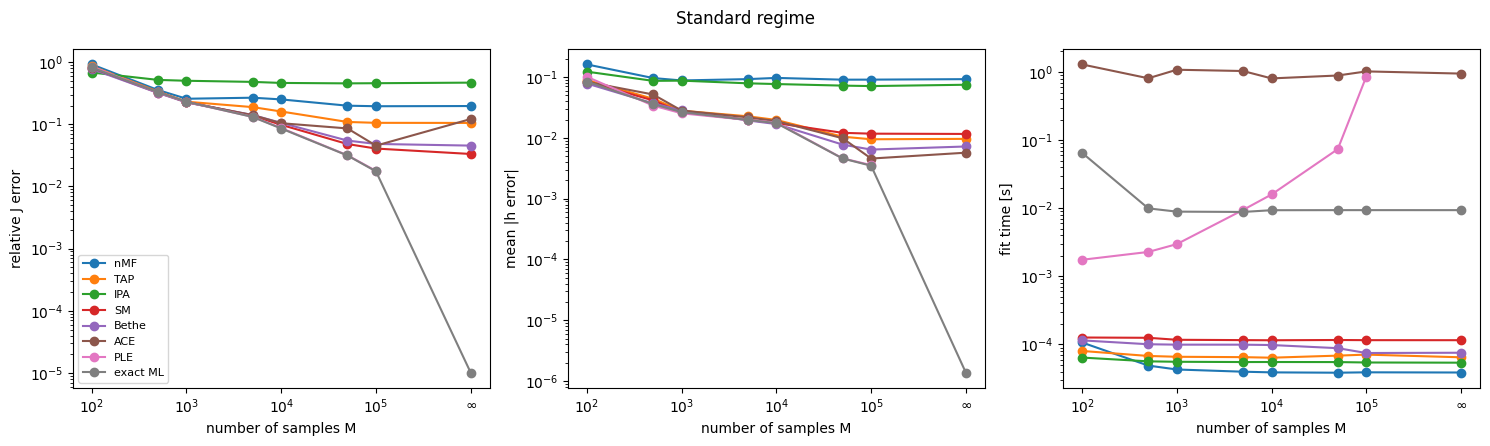

In [4]:
model = IsingModel(n_sites=10, backend=BACKEND)
h, J = model.random_params(loc_h=0.0, scale_h=0.3, loc_J=0.0, scale_J=0.3, seed=0)

datasets = get_datasets(model, h, J, seed=0)

results_standard = run_experiment(model, h, J, datasets)
plot_results(results_standard, "Standard regime")


In the standard regime the whole system is coupled weakly. This makes the assumptions of the IPA break down: it treats every pair as isolated, so the indirect correlations that go through all the other sites are counted as direct couplings. This results in this method having the worst score for the couplings. Furthermore, the mean field methods do not gain any improvement in performance after around $10^4$ samples, as their error is then set by the approximation and not by the data. Finally, the performance of the PLE and exact MLE is near identical.

### Strongly coupled regime

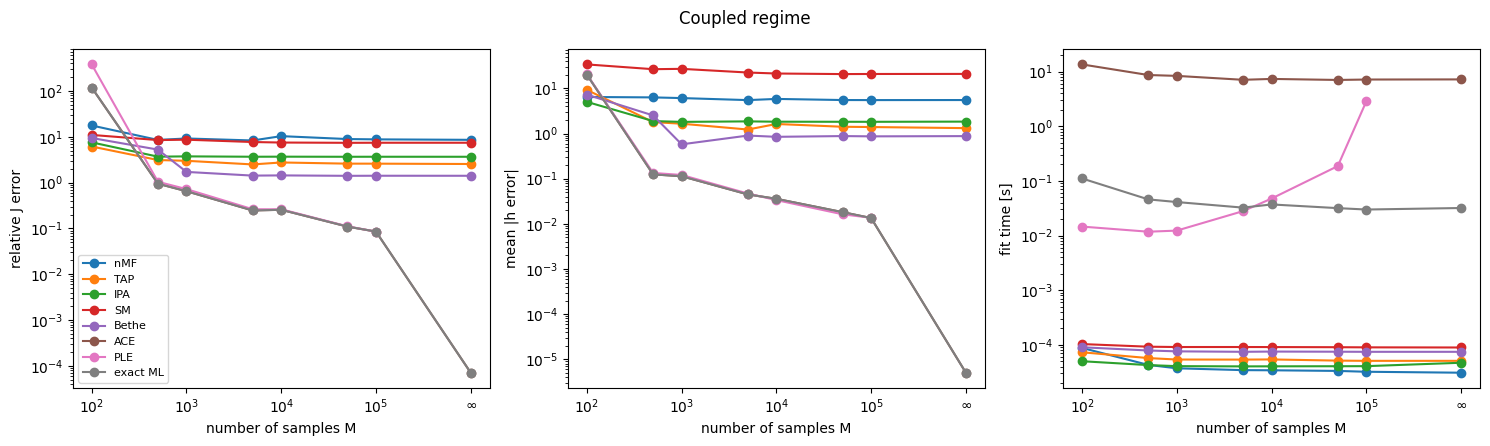

In [5]:
model = IsingModel(n_sites=10, backend=BACKEND)
h, J = model.random_params(loc_h=0.0, scale_h=0.3, loc_J=0.2, scale_J=0.3, seed=0)

datasets = get_datasets(model, h, J, seed=0)

results_strong_coupling = run_experiment(model, h, J, datasets)
plot_results(results_strong_coupling, "Coupled regime")

In this regime it is clear that all of the assumptions for the mean field approximations break down as all of these methods exhibit large errors. A relative error above 1 even means that they do worse than just guessing $J = 0$. The MLE and PLE are still identical and the best in regimes with enough samples. In this regime MLE shows that recovery of parameters is possible with infinite data, but even $10^5$ samples does not seem enough. ACE is hidden behind the MLE here: because everything is strongly correlated almost all clusters are kept, up to the full system, which is the same as exact MLE but around 300 times slower. Finally, if this plot is compared to the standard regime it is clear that all methods perform worse on this type of data.

### Limited strong coupling regime

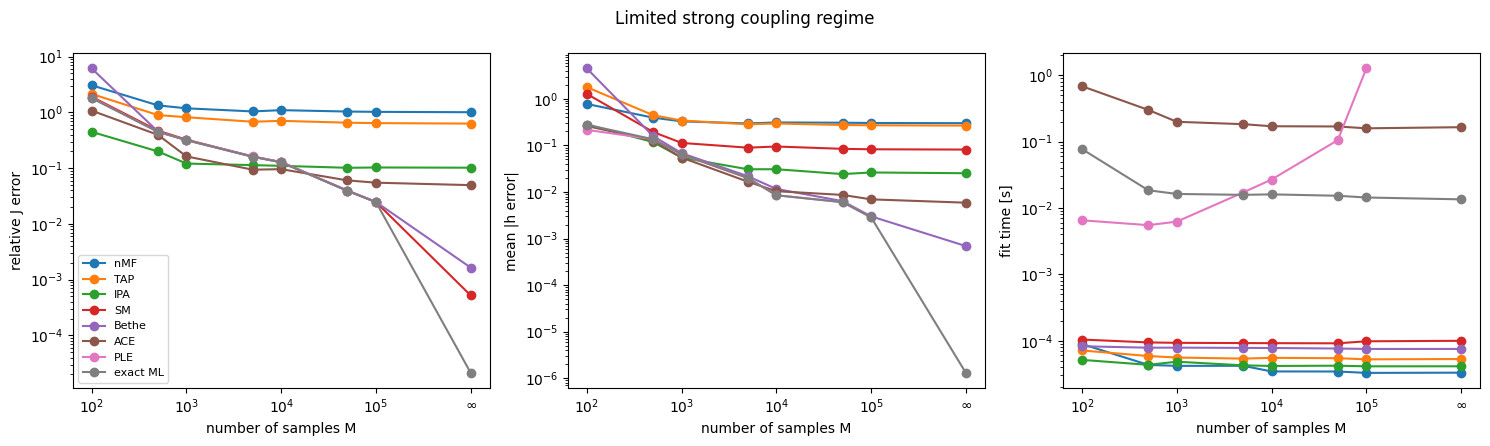

In [6]:
model = IsingModel(n_sites=10, backend=BACKEND)
h, J = model.random_params(loc_h=0.0, scale_h=0.3, loc_J=0.0, scale_J=0.05, seed=0)

xp = model.array_backend.xp
J = np.array(J)
for i, j, value in [(0, 1, 1.0), (4, 5, 1.0), (3, 7, 0.8), (2, 6, -1.2)]:
    J[i, j] = J[j, i] = value
J = xp.asarray(J)

datasets = get_datasets(model, h, J, seed=0)

results_sparse = run_experiment(model, h, J, datasets)
plot_results(results_sparse, "Limited strong coupling regime")

In the sparse regime the Sessak Monasson and Bethe approximations perform considerably better than their mean field counterparts. The strong pairs do not share any sites and the background is weak, so the system is nearly tree-like, which is where the Bethe approximation is exact. The naive mean field and TAP methods on the other hand cannot handle the strong couplings. ACE levels off at a relative error of around 0.05, as the clusters that are only connected by the weak background couplings fall below the threshold and these couplings are never fitted. The MLE and PLE methods remain identical in performance.

### Biased magnetization regime

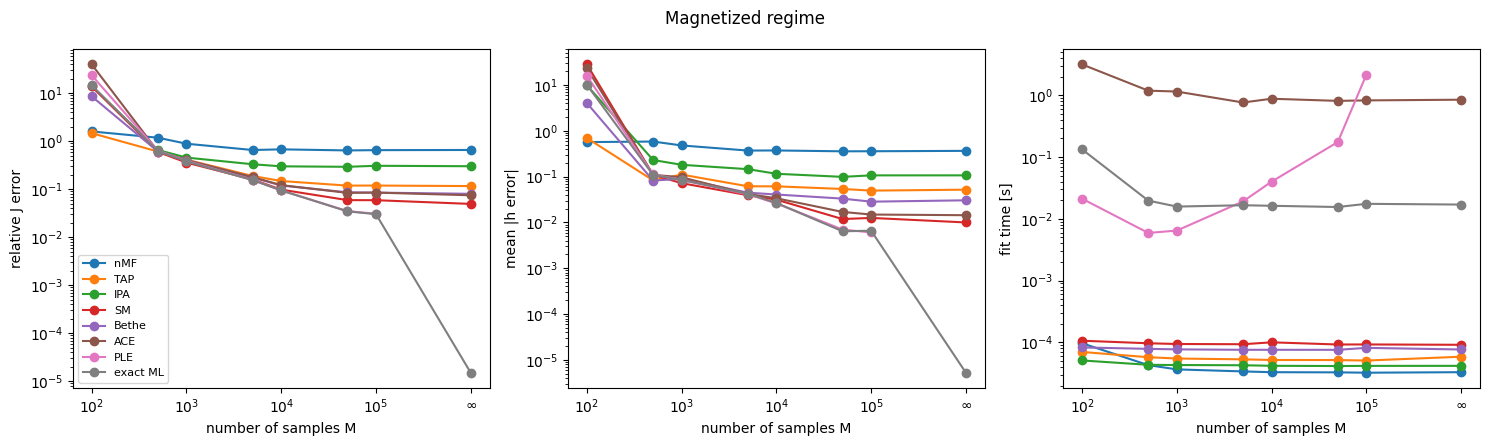

In [7]:
model = IsingModel(n_sites=10, backend=BACKEND)
h, J = model.random_params(loc_h=0.5, scale_h=0.3, loc_J=0.0, scale_J=0.3, seed=0)

datasets = get_datasets(model, h, J, seed=0)

results_magnetized = run_experiment(model, h, J, datasets)
plot_results(results_magnetized, "Magnetized regime")

In the magnetized regime the naive mean field and IPA assumptions break down and their errors become large, while the Sessak Monasson, Bethe and TAP methods still perform reasonably well. Furthermore, it is clear that the MLE can still recover the correct parameters at infinite samples, and with $10^5$ generated samples the errors in $h$ and $J$ are only slightly larger than in the standard regime. PLE and MLE still have the same performance error-wise.

In all regimes the errors of the MLE, PLE and ACE blow up at 100 samples. This is because none of these methods are regularized here, and 100 samples is too few to recover all the parameters without overfitting. Adding L2 regularization prevents this.


### Sites time complexity

N = 4 done
N = 6 done
N = 8 done
N = 10 done
N = 12 done
N = 14 done
N = 16 done
N = 18 done
N = 20 done


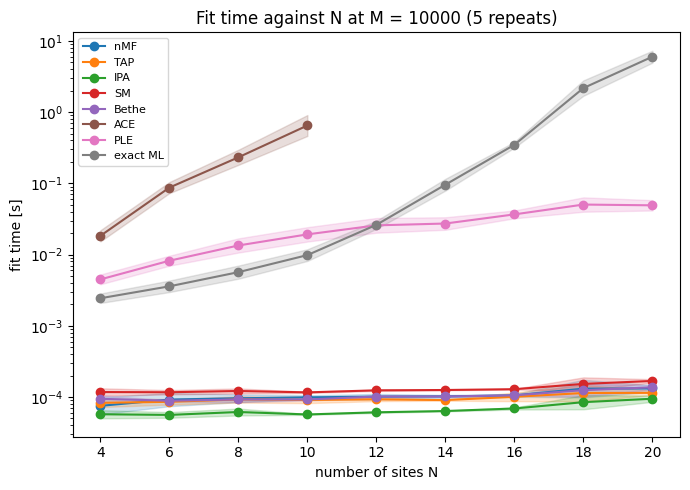

In [8]:
N_VALUES = [4, 6, 8, 10, 12, 14, 16, 18, 20]
M_FIXED = 10_000
N_REPEATS = 5
MAX_SITES = {"ACE": 10}

results_sites = []
for n in N_VALUES:
    model = IsingModel(n_sites=n, backend=BACKEND)
    scale_J = 0.3 * np.sqrt(10 / n)
    methods = {name: f for name, f in METHODS.items() if n <= MAX_SITES.get(name, np.inf)}
    for seed in range(N_REPEATS):
        h, J = model.random_params(loc_h=0.0, scale_h=0.3, loc_J=0.0, scale_J=scale_J, seed=seed)
        datasets = get_datasets(model, h, J, seed=seed, sample_sizes=[M_FIXED])
        datasets.pop(np.inf)
        for row in run_experiment(model, h, J, datasets, methods=methods):
            results_sites.append({**row, "N": n, "seed": seed})
    print(f"N = {n} done")


def plot_time_vs_sites(results, M, title):
    fig, ax = plt.subplots(figsize=(7, 5))
    for name in dict.fromkeys(r["method"] for r in results):
        rows = [r for r in results if r["method"] == name and r["M"] == M]
        if not rows:
            continue
        ns = sorted({r["N"] for r in rows})
        logs = [np.log10([r["time"] for r in rows if r["N"] == n]) for n in ns]
        mean = np.array([l.mean() for l in logs])
        std = np.array([l.std() for l in logs])
        line, = ax.plot(ns, 10**mean, "o-", label=name)
        ax.fill_between(ns, 10**(mean - std), 10**(mean + std), color=line.get_color(), alpha=0.2)
    ax.set(yscale="log", xlabel="number of sites N", ylabel="fit time [s]", title=title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


plot_time_vs_sites(results_sites, M_FIXED, f"Fit time against N at M = {M_FIXED} ({N_REPEATS} repeats)")

In this plot it is clear that the exact MLE scales exponentially with the number of sites: from $N = 10$ onwards the fit time grows by roughly a factor $2^N$, from around 0.06 s at 10 sites to around 70 s at 20 sites. Below $N \approx 11$ the exact MLE is actually faster than the PLE, as enumerating $2^N$ states is then cheaper than going over all $10^4$ samples, but above this point the PLE quickly becomes the faster option. The PLE only grows mildly with $N$, as its cost scales polynomially. Furthermore, the mean field methods stay at a fraction of a millisecond, as at these system sizes their time is dominated by overhead rather than the matrix inversion itself. Finally, ACE grows steeply as well, because in this dense regime the number of clusters that are kept increases quickly with the system size. For this reason ACE was only run up to 10 sites.
